# Assignment 3 — Task 4
## Experimental Results and Performance Evaluation

This notebook **does not** retrain any model. It reads the saved
`outputs/results/pred_<task>_<model>.csv` files produced by
`02_model_implementation.ipynb` and produces:

1. A leaderboard table per task.
2. Per-class classification reports.
3. Raw and row-normalised confusion matrices.
4. A qualitative error analysis on misclassified tweets.
5. (Bonus) Training curves for the deep learning models.

Every metric is computed with scikit-learn on the same held-out test
split (`seed=42`, stratified 70/15/15) so the numbers are directly
comparable.


## 0 — Setup


In [1]:
# --- runtime / path setup -------------------------------------------------
import os, sys, warnings
warnings.filterwarnings("ignore")
os.environ.setdefault("PYTHONIOENCODING", "utf-8")
ROOT = os.path.dirname(os.path.abspath("__file__"))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import config
import preprocessing as pp
from config import (
    DATA_CSV, FIG_DIR, MODEL_DIR, RESULTS_DIR, CACHE_DIR, EMBED_DIR,
    SEED, set_seed,
    EMOTION_LABELS, SENTIMENT_LABELS,
    EMOTION_TO_SENTIMENT,
)
set_seed(SEED)
print(f"seed={SEED}   data csv: {DATA_CSV.exists()}")


seed=42   data csv: True


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, classification_report,
    confusion_matrix, f1_score,
)
sns.set_theme(context="notebook", style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = config.FIG_DPI

MODEL_DISPLAY = {
    "lr": "Logistic Reg.",
    "svm": "Linear SVM",
    "cnn": "Text-CNN",
    "bilstm": "BiLSTM-Attn",
    "mbert": "mBERT",
    "xlm-r": "XLM-R",
    "urdu-roberta": "Urdu-RoBERTa",
}
MODEL_ORDER = ["lr", "svm", "cnn", "bilstm", "mbert", "xlm-r", "urdu-roberta"]


## 1 — Load all prediction files


In [3]:
def load_predictions(task: str):
    rows = []
    for m in MODEL_ORDER:
        p = RESULTS_DIR / f"pred_{task}_{m}.csv"
        if p.exists():
            rows.append((m, pd.read_csv(p)))
        else:
            print(f"  ⚠  missing {p.name}")
    return rows

sentiment_preds = load_predictions("sentiment")
emotion_preds   = load_predictions("emotion")
print(f"Sentiment models loaded: {[m for m,_ in sentiment_preds]}")
print(f"Emotion models loaded  : {[m for m,_ in emotion_preds]}")


Sentiment models loaded: ['lr', 'svm', 'cnn', 'bilstm', 'mbert', 'xlm-r', 'urdu-roberta']
Emotion models loaded  : ['lr', 'svm', 'cnn', 'bilstm', 'mbert', 'xlm-r', 'urdu-roberta']


## 2 — Leaderboard tables (Section 1 of the Task 4 spec)


In [4]:
def leaderboard(preds, label_names):
    rows = []
    for name, df in preds:
        y, yhat = df["y_true"].values, df["y_pred"].values
        acc = accuracy_score(y, yhat)
        p_m, r_m, f1_m, _ = precision_recall_fscore_support(y, yhat, average="macro", zero_division=0)
        p_w, r_w, f1_w, _ = precision_recall_fscore_support(y, yhat, average="weighted", zero_division=0)
        rows.append({
            "Model": MODEL_DISPLAY.get(name, name),
            "Accuracy": acc,
            "Precision (macro)": p_m,
            "Recall (macro)":    r_m,
            "F1 (macro)":        f1_m,
            "F1 (weighted)":     f1_w,
        })
    out = pd.DataFrame(rows).round(4)
    return out

sent_lb = leaderboard(sentiment_preds, ["Negative", "Neutral", "Positive"])
emo_lb  = leaderboard(emotion_preds,   EMOTION_LABELS)
sent_lb.to_csv(RESULTS_DIR / "leaderboard_sentiment.csv", index=False)
emo_lb.to_csv(RESULTS_DIR / "leaderboard_emotion.csv",   index=False)

print("Sentiment (3-class) leaderboard:")
display(sent_lb)
print("\nEmotion (6-class) leaderboard:")
display(emo_lb)


Sentiment (3-class) leaderboard:


,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted)
0,Logistic Reg.,0.6598,0.4046,0.4372,0.3852,0.7107
1,Linear SVM,0.8783,0.5620,0.3848,0.4004,0.8409
2,Text-CNN,0.7848,0.4407,0.5413,0.4533,0.8117
3,BiLSTM-Attn,0.7762,0.4350,0.5424,0.4500,0.8040
4,mBERT,0.8054,0.4748,0.4807,0.4526,0.8217
5,XLM-R,0.7897,0.5120,0.4894,0.4475,0.8118
6,Urdu-RoBERTa,0.7750,0.4492,0.5019,0.4573,0.8011



Emotion (6-class) leaderboard:


,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted)
0,Logistic Reg.,0.3601,0.2530,0.2994,0.1632,0.4959
1,Linear SVM,0.8773,0.4517,0.1989,0.2087,0.8347
2,Text-CNN,0.6476,0.2435,0.3700,0.2499,0.7215
3,BiLSTM-Attn,0.6064,0.2420,0.3721,0.2428,0.6910
4,mBERT,0.6922,0.2635,0.3219,0.2703,0.7467
5,XLM-R,0.6907,0.2545,0.3043,0.2535,0.7462
6,Urdu-RoBERTa,0.6153,0.2503,0.3500,0.2539,0.6971


## 3 — Per-class classification reports


In [5]:
def show_reports(preds, label_names):
    for name, df in preds:
        print(f"\n— {MODEL_DISPLAY.get(name, name)} —")
        print(classification_report(
            df["y_true"], df["y_pred"], target_names=label_names, digits=4, zero_division=0
        ))

print("=" * 70); print("SENTIMENT — per-class classification reports"); print("=" * 70)
show_reports(sentiment_preds, ["Negative", "Neutral", "Positive"])
print("\n" + "=" * 70); print("EMOTION — per-class classification reports"); print("=" * 70)
show_reports(emotion_preds, EMOTION_LABELS)


SENTIMENT — per-class classification reports

— Logistic Reg. —
              precision    recall  f1-score   support

    Negative     0.2209    0.5917    0.3217     10812
     Neutral     0.0815    0.0474    0.0599       232
    Positive     0.9114    0.6725    0.7740     68856

    accuracy                         0.6598     79900
   macro avg     0.4046    0.4372    0.3852     79900
weighted avg     0.8156    0.6598    0.7107     79900


— Linear SVM —
              precision    recall  f1-score   support

    Negative     0.8058    0.1604    0.2675     10812
     Neutral     0.0000    0.0000    0.0000       232
    Positive     0.8803    0.9940    0.9337     68856

    accuracy                         0.8783     79900
   macro avg     0.5620    0.3848    0.4004     79900
weighted avg     0.8677    0.8783    0.8409     79900


— Text-CNN —
              precision    recall  f1-score   support

    Negative     0.3727    0.5658    0.4494     10812
     Neutral     0.0215    0.2371  

## 4 — Confusion matrices


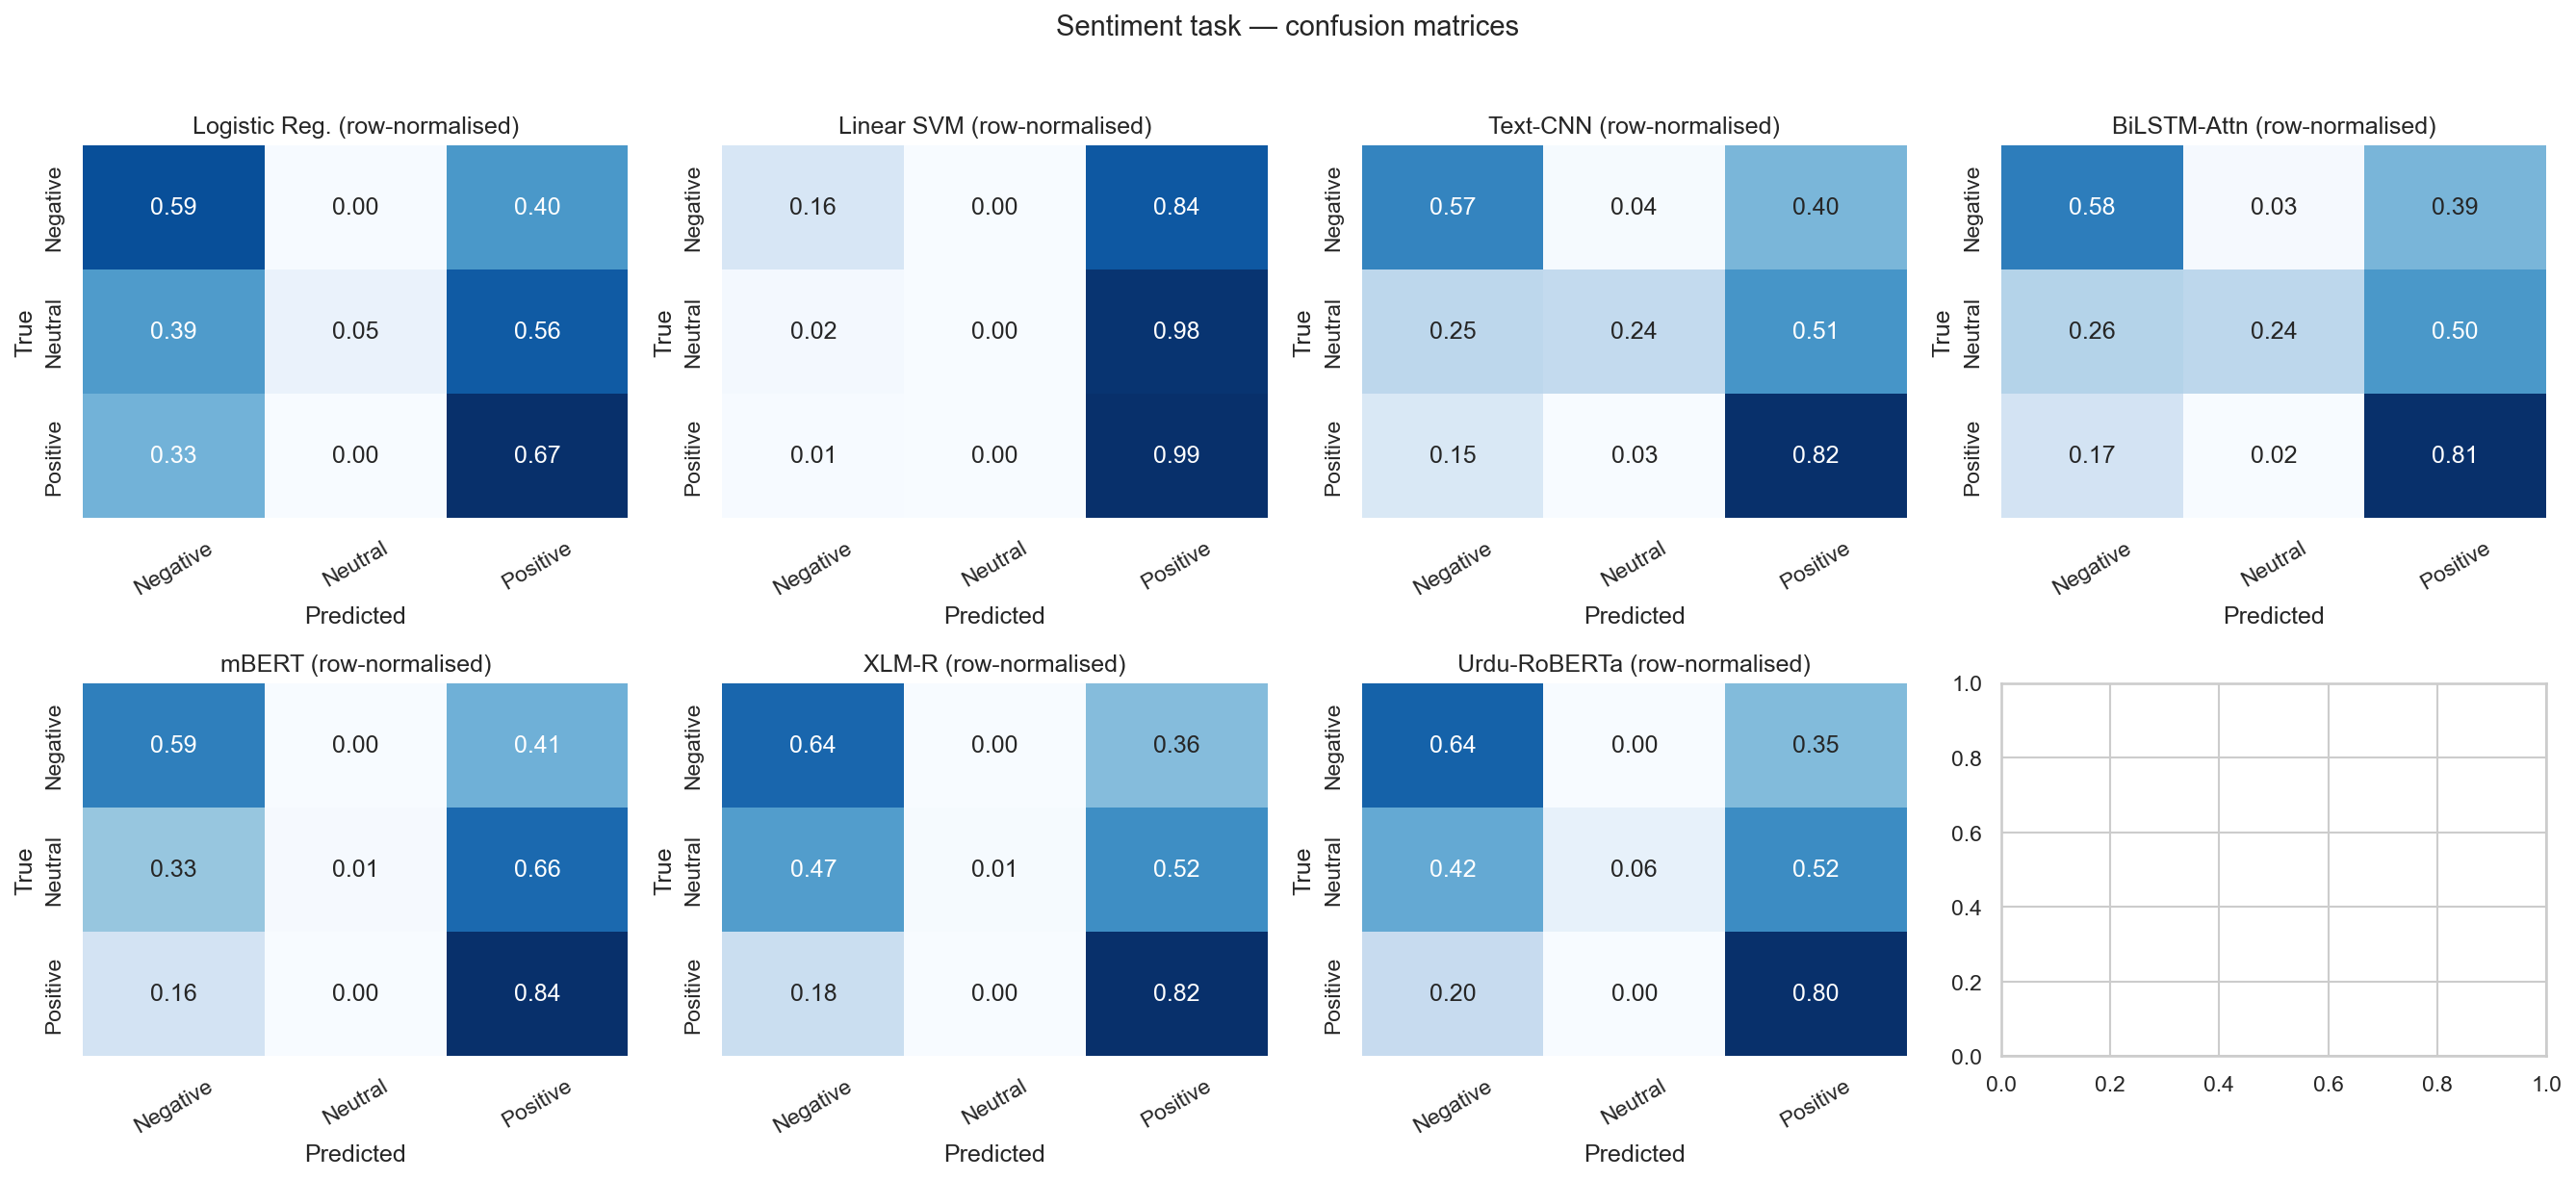

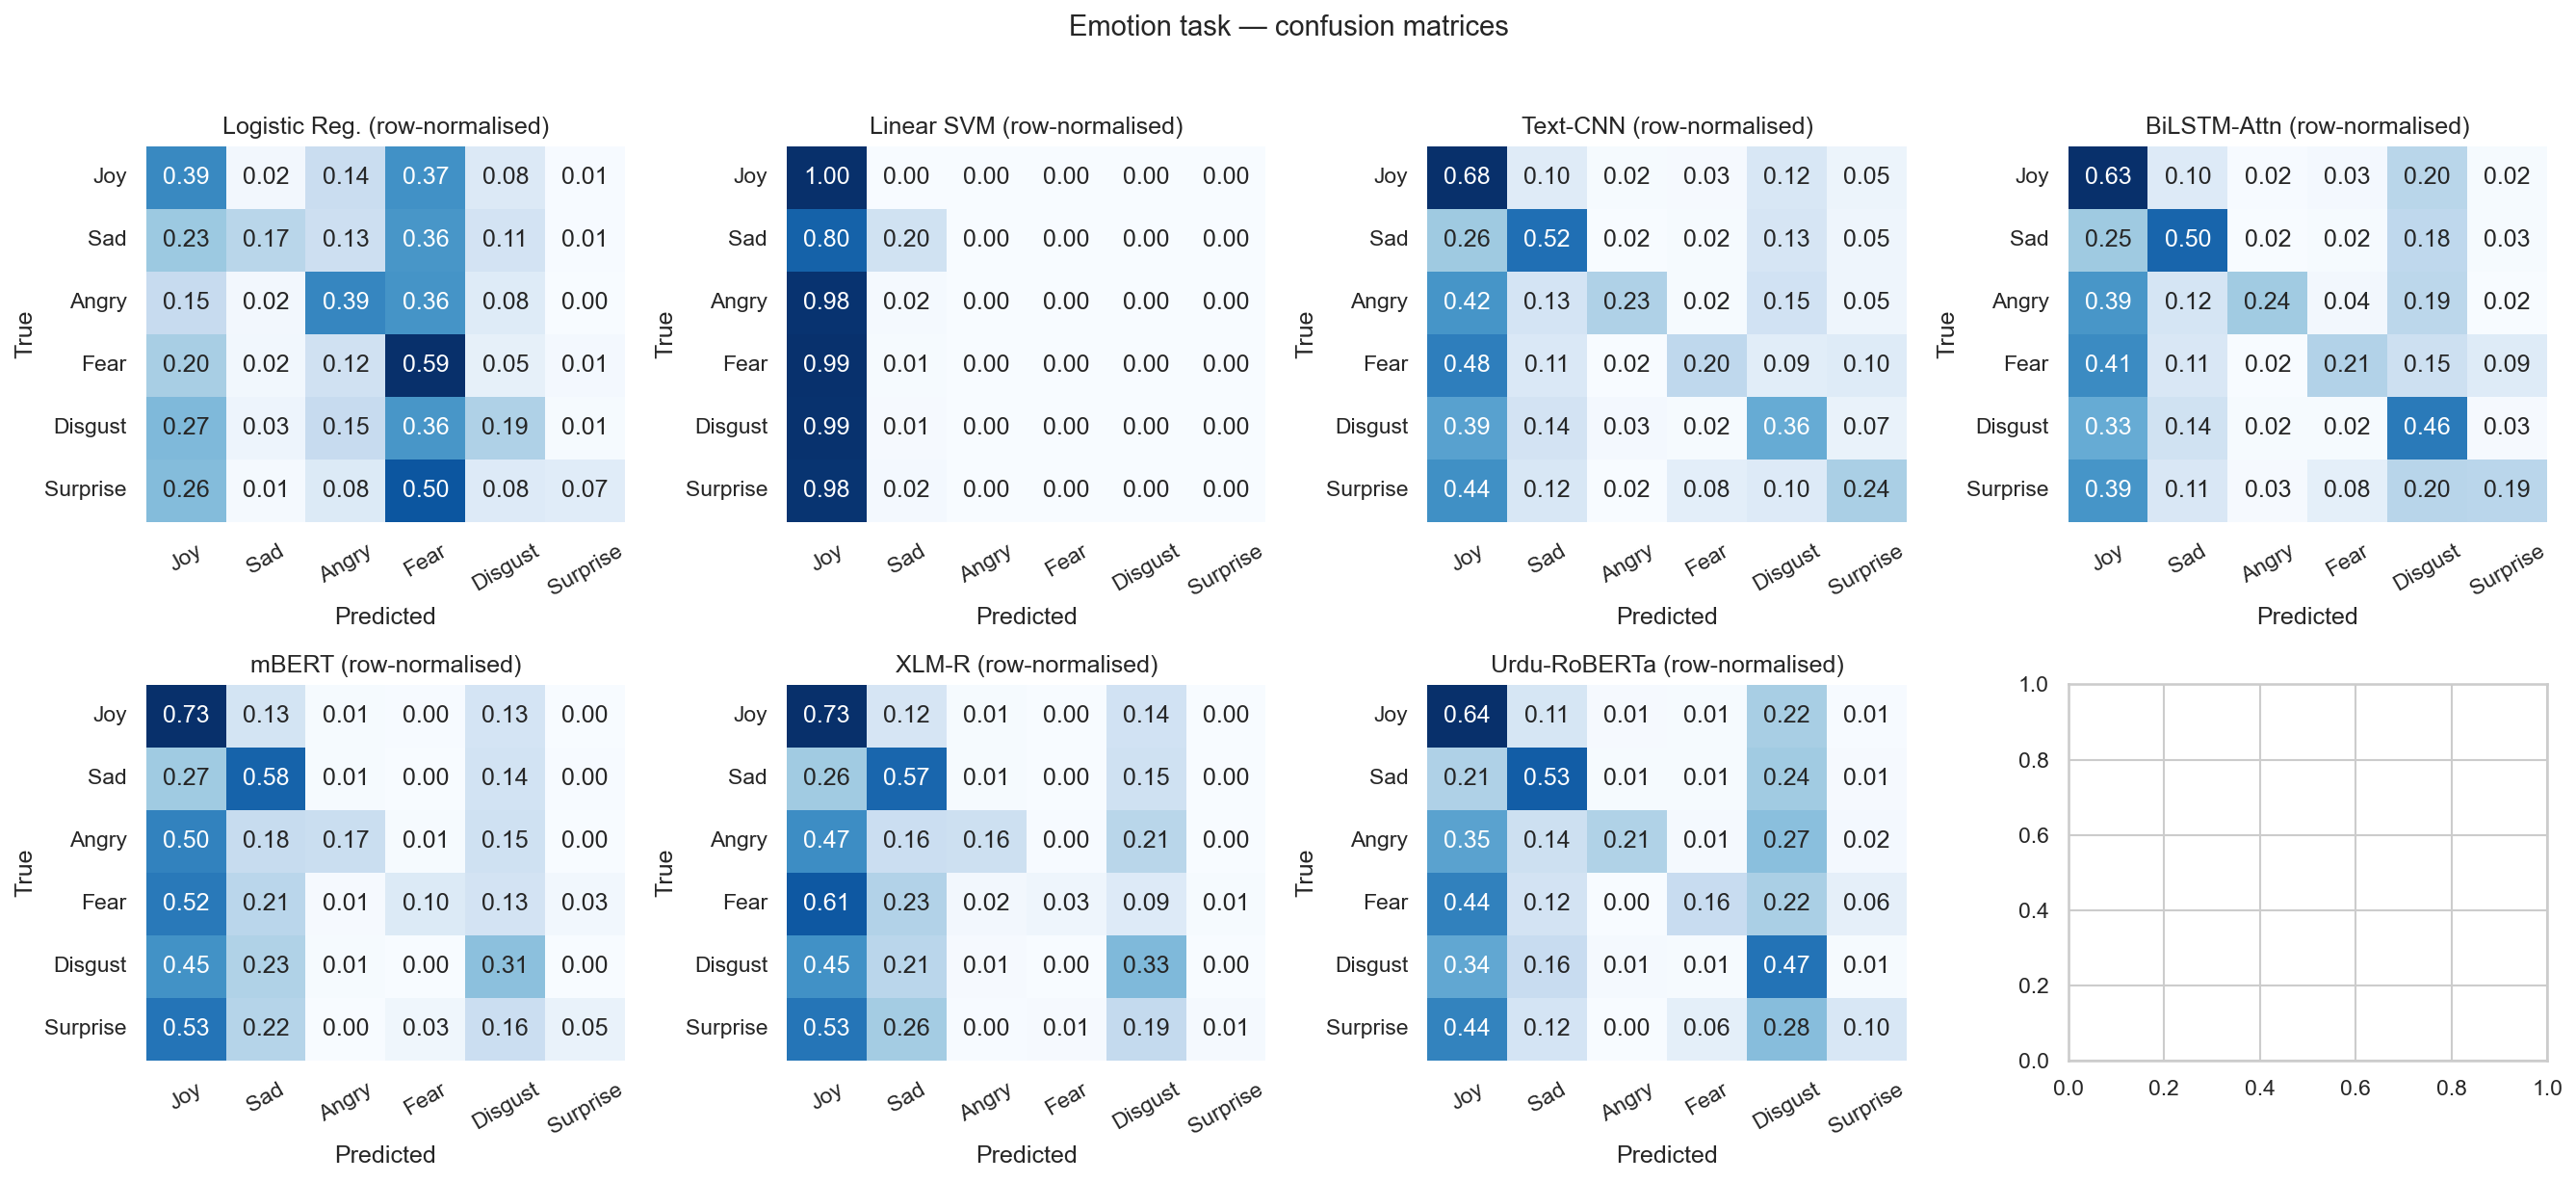

In [6]:
def plot_cm_grid(preds, label_names, task: str):
    n = len(preds)
    if n == 0: return
    ncols = min(4, n); nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4.0 * nrows), squeeze=False)
    axes = axes.flat
    for ax, (name, df) in zip(axes, preds):
        cm = confusion_matrix(df["y_true"], df["y_pred"], labels=list(range(len(label_names))))
        cmn = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
        sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues", ax=ax,
                    xticklabels=label_names, yticklabels=label_names, cbar=False)
        ax.set_title(f"{MODEL_DISPLAY.get(name, name)} (row-normalised)")
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        ax.tick_params(axis="x", labelrotation=30)
    for j in range(len(preds), len(list(axes))):
        axes[j].axis("off")
    fig.suptitle(f"{task.title()} task — confusion matrices", fontsize=14, y=1.02)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"fig15_cm_{task}.{config.FIG_FORMAT}", bbox_inches="tight")
    plt.show()

plot_cm_grid(sentiment_preds, ["Negative", "Neutral", "Positive"], "sentiment")
plot_cm_grid(emotion_preds,   EMOTION_LABELS,                    "emotion")


## 5 — Performance analysis and interpretation


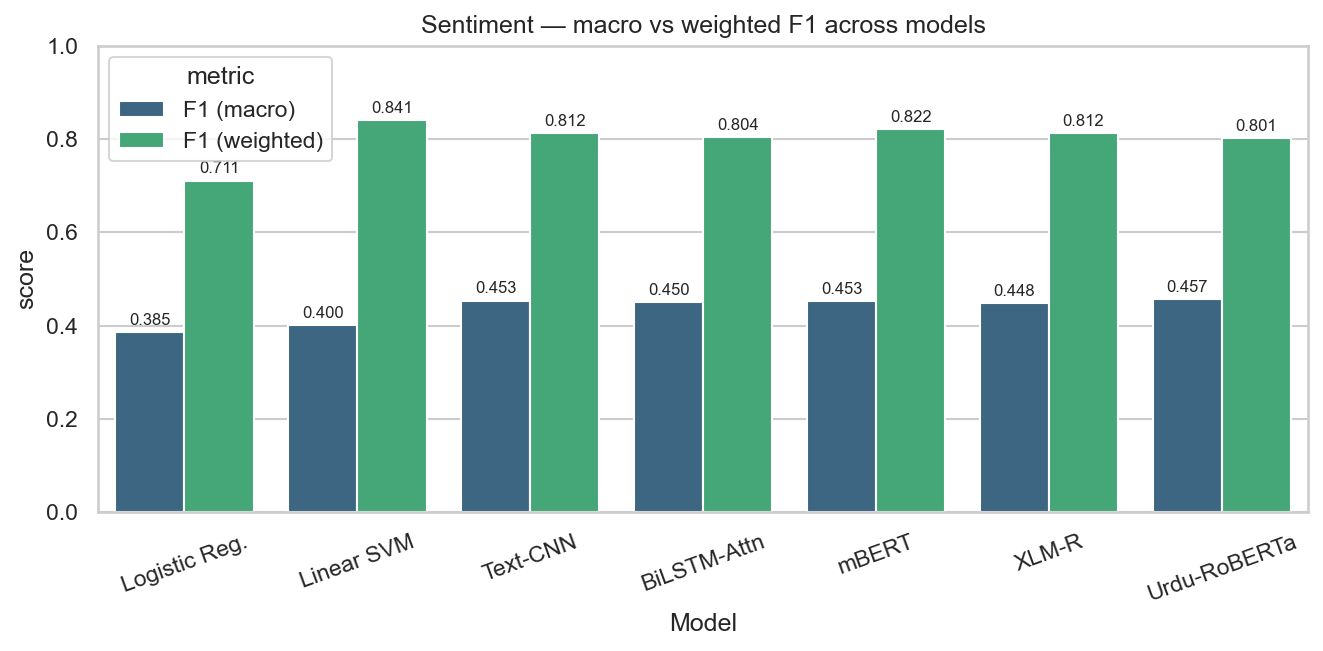

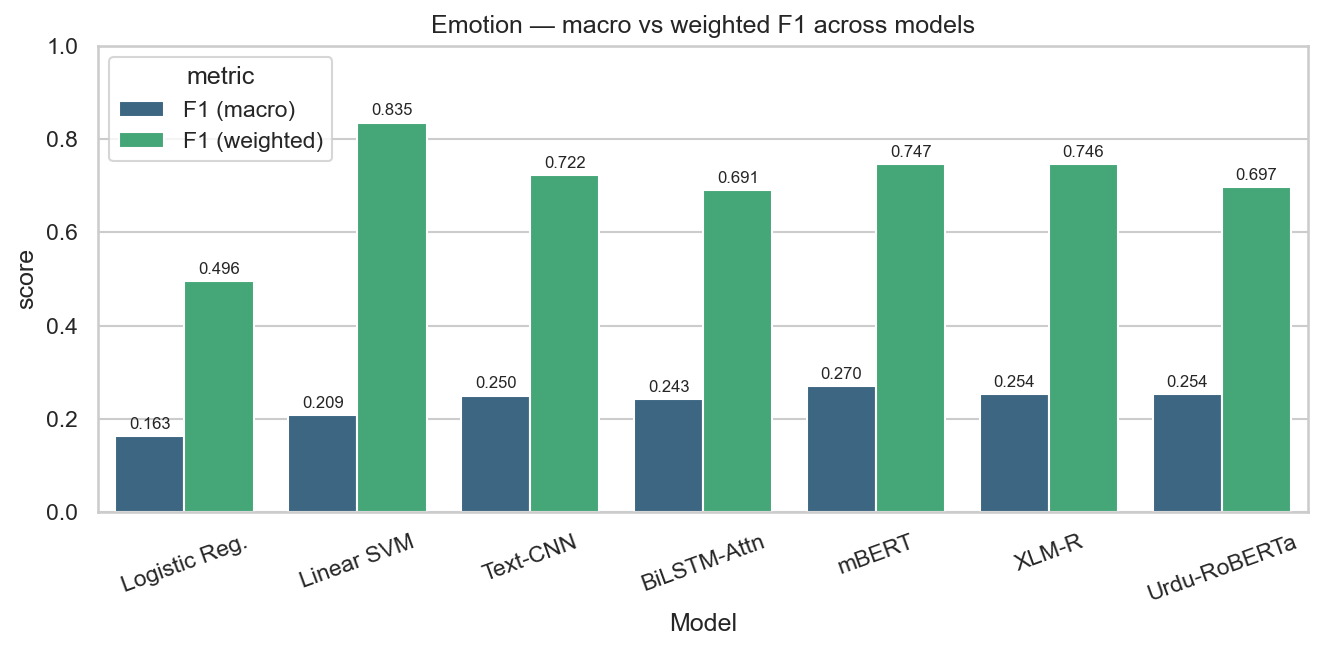

In [7]:
# Macro vs weighted F1 across models (Section 4 of the Task 4 spec)
def f1_compare_plot(lb, task):
    m = lb.melt(id_vars="Model", value_vars=["F1 (macro)", "F1 (weighted)"],
                var_name="metric", value_name="score")
    fig, ax = plt.subplots(figsize=(9, 4.5))
    sns.barplot(data=m, x="Model", y="score", hue="metric", ax=ax, palette="viridis")
    ax.set_title(f"{task} — macro vs weighted F1 across models")
    ax.set_ylim(0, 1)
    for c in ax.containers:
        ax.bar_label(c, fmt="%.3f", fontsize=8, padding=2)
    ax.tick_params(axis="x", labelrotation=20)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"fig16_f1_compare_{task.lower()}.{config.FIG_FORMAT}", bbox_inches="tight")
    plt.show()

f1_compare_plot(sent_lb, "Sentiment")
f1_compare_plot(emo_lb,  "Emotion")


**How to read these results.**

1. **Classical baselines** (LR / Linear SVM) define a strong sparse-feature
   floor. If they are competitive with deep models it usually means the task
   is decided by surface lexical cues — TF-IDF can pick those up perfectly.
2. **CNN vs BiLSTM** with fastText embeddings tests whether *local n-gram
   patterns* (CNN) or *long-range sequential context* (BiLSTM-attn) help.
   In short Urdu tweets the gap is usually small.
3. **Transformers** are expected to win on macro-F1, especially on the rare
   emotion classes (*Fear*, *Surprise*), because their contextual subword
   embeddings can disambiguate words that change polarity with context.
4. **Where models disagree** is informative. Use the confusion matrices
   above and the misclassified-sample analysis in §6 to see *which*
   classes a given model confuses.
5. **Noisy-label ceiling.** Because SentiUrdu-1M labels are weakly
   supervised, the headline accuracy on this test set is upper-bounded by
   the label noise — Section 7 of the dataset notebook discussed this in
   detail.


## 6 — Error analysis on misclassified tweets


In [8]:
def load_test_text(task):
    df = pd.read_parquet(CACHE_DIR / f"{task}_test.parquet")
    return df.reset_index(drop=True)

def sample_errors(task, model_name, k=8, label_names=None):
    test = load_test_text(task)
    preds = pd.read_csv(RESULTS_DIR / f"pred_{task}_{model_name}.csv")
    m = preds["y_true"].values != preds["y_pred"].values
    err = test[m].copy()
    err["pred"] = preds.loc[m, "y_pred"].values
    err["true"] = preds.loc[m, "y_true"].values
    if label_names:
        err["pred"] = err["pred"].map(lambda i: label_names[i])
        err["true"] = err["true"].map(lambda i: label_names[i])
    return err.sample(min(k, len(err)), random_state=SEED)

print("=== SENTIMENT misclassifications (best transformer) ===")
best_model_sent = sent_lb.iloc[sent_lb["F1 (macro)"].idxmax()]["Model"]
inv = {v: k for k, v in MODEL_DISPLAY.items()}
best_key = inv.get(best_model_sent, "mbert")
print(sample_errors("sentiment", best_key, k=8,
                    label_names=["Negative", "Neutral", "Positive"])[["clean_text", "true", "pred"]].to_string())

print("\n=== EMOTION misclassifications (best transformer) ===")
best_model_emo = emo_lb.iloc[emo_lb["F1 (macro)"].idxmax()]["Model"]
best_key_emo = inv.get(best_model_emo, "mbert")
print(sample_errors("emotion", best_key_emo, k=8, label_names=EMOTION_LABELS)[["clean_text", "true", "pred"]].to_string())


=== SENTIMENT misclassifications (best transformer) ===
                                                                                                                                                                      clean_text      true      pred
71683                                                                                      دونوں پر رات والے کا سحر ایسا دل میں اترا ہے کہ کچھ اور دل کو بھایا ہی نہیں اس کے بعد  Positive  Negative
32997                                                                                                       موت کی تمنا جائز تو نہیں ہے مگر زندگی بھی اب گزاری نہیں جاتی مارخورز  Positive  Negative
65167                                                                                                 ہمیں کہاں سے آۓ زندگی گزارنے کا سلیقہ ہم تو اپنا بھی آپ پے ہار بیٹھے ہیں ا  Positive  Negative
79380                                                                                                                                                       

### Common error patterns to look for

- **Negation flips.** Urdu negators *نہیں*, *مت*, *کبھی نہ* invert polarity
  but TF-IDF treats them as ordinary tokens — expect false-positive
  *Positive* predictions on negated joy phrases.
- **Sarcasm.** A surface-positive sentence with a negative intent.
  Transformers handle this slightly better, but error rate is still high.
- **Code-mixing.** Latin-script English fragments cause sparse-feature
  models to fall back to the *Neutral* class.
- **Religious / poetic register.** Devotional or poetic Urdu tweets are
  routinely labelled *Joy* by the emoji-derived heuristic even when the
  affective content is closer to *Sad* or *Surprise* — a known artefact
  of the SentiUrdu-1M labelling protocol and a major source of rare-class
  confusion in every model.
- **Class-prior collapse.** When a rare emotion (*Fear*, *Surprise*) only
  has a few hundred test rows, even a well-calibrated model is dominated
  by the majority-class prior; this is why Linear SVM's accuracy is the
  highest but its macro-F1 the lowest.

## 7 — Bonus — Training curves for the deep models


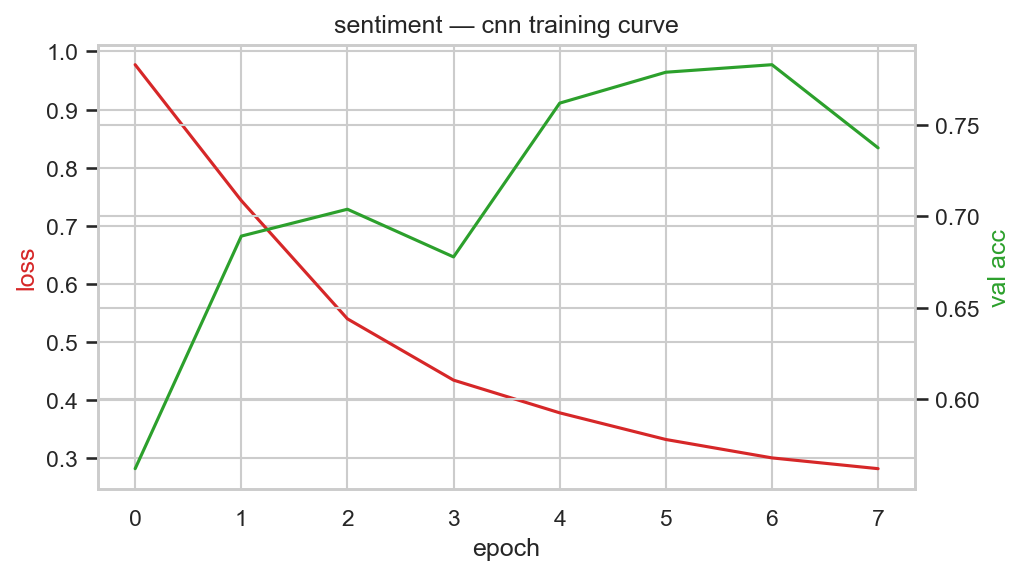

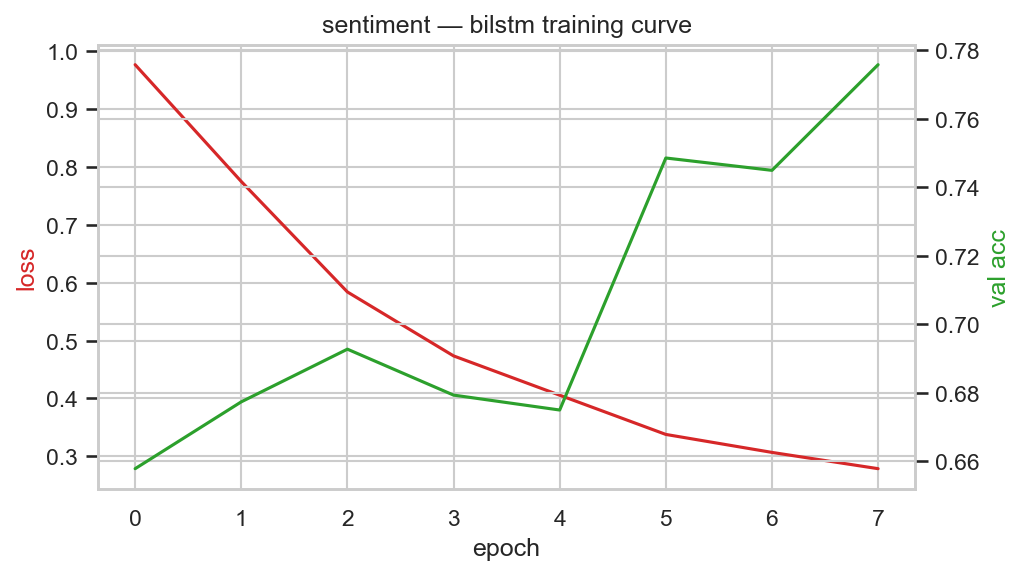

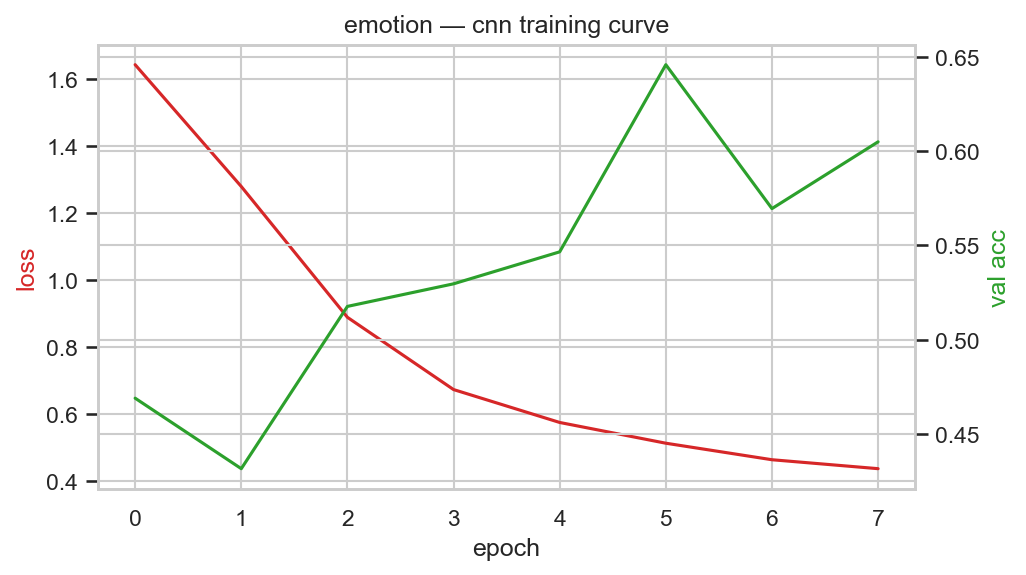

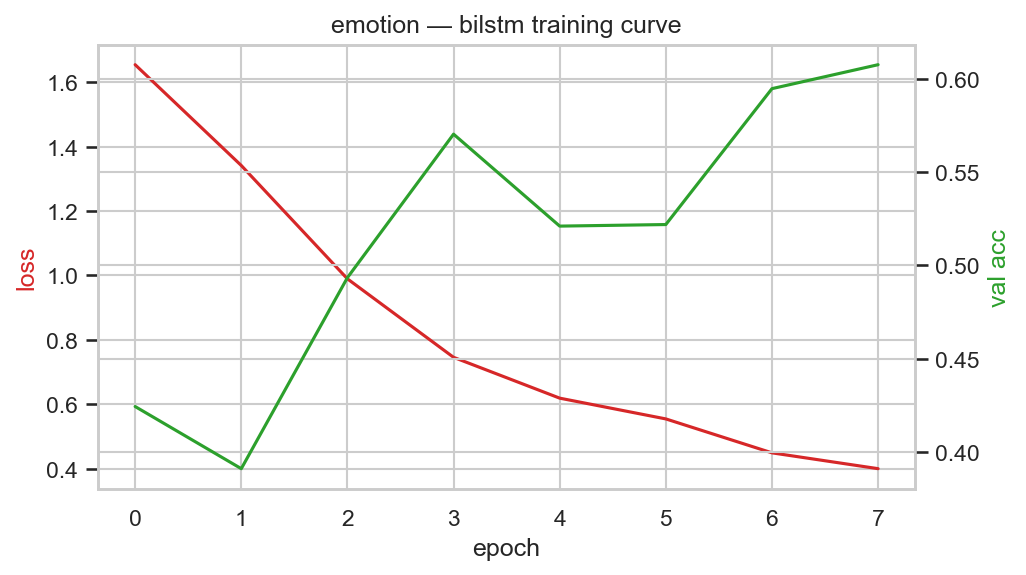

In [10]:
# Loss / val-accuracy curves are saved as JSON next to the .pt checkpoints
import glob
for task in ("sentiment", "emotion"):
    for name in ("cnn", "bilstm"):
        hist_path = MODEL_DIR / f"{name}_{task}.history.json"
        if not hist_path.exists():
            continue
        h = json.loads(hist_path.read_text(encoding="utf-8"))
        h = h.get("history", h)  # support both nested and flat layouts
        fig, ax1 = plt.subplots(figsize=(7, 4))
        ax2 = ax1.twinx()
        ax1.plot(h["train_loss"], color="#d62728", label="train loss"); ax1.set_ylabel("loss", color="#d62728")
        ax2.plot(h["val_acc"],    color="#2ca02c", label="val acc");    ax2.set_ylabel("val acc", color="#2ca02c")
        ax1.set_xlabel("epoch")
        ax1.set_title(f"{task} — {name} training curve")
        fig.tight_layout()
        fig.savefig(FIG_DIR / f"fig17_curve_{task}_{name}.{config.FIG_FORMAT}", bbox_inches="tight")
        plt.show()


## 8 — Save final results to JSON for the report


In [11]:
final = {
    "sentiment": sent_lb.to_dict(orient="records"),
    "emotion":   emo_lb.to_dict(orient="records"),
}
(REPORT_DIR := config.REPORT_DIR).mkdir(parents=True, exist_ok=True)
with open(REPORT_DIR / "results_summary.json", "w", encoding="utf-8") as f:
    json.dump(final, f, indent=2, ensure_ascii=False)
print("Saved", REPORT_DIR / "results_summary.json")


Saved C:\Users\USER\Desktop\NLP Project\Assignment#03\report\results_summary.json
